# 17 - AVL - Ávore de Busca Binária Balanceada

### Desenhar árvore vertical

In [ ]:
# ------------------------------------------------------------
# Função para desenhar a árvore em formato de texto (ASCII)
# ------------------------------------------------------------
def desenhar_arvore_vertical(raiz):
    linhas, *_ = _desenhar_rec(raiz)  # Monta o desenho da árvore

    # Percorre cada linha do desenho
    for linha in linhas:
        print(linha)                  # Imprime cada linha


# Função recursiva que monta o desenho
def _desenhar_rec(no):
    # Se o nó for vazio
    if no is None:
        return [" "], 1, 1, 0

    # Se for folha
    if no.esquerda is None and no.direita is None:
        linha = f"|{no.valor}|"
        largura = len(linha)
        return [linha], largura, 1, largura // 2

    esquerda, largura_esq, altura_esq, meio_esq = _desenhar_rec(no.esquerda)
    direita, largura_dir, altura_dir, meio_dir = _desenhar_rec(no.direita)

    valor = f"|{no.valor}|"
    largura_valor = len(valor)

    primeira_linha = " " * (meio_esq + 1) + "_" * (largura_esq - meio_esq - 1)
    primeira_linha += valor
    primeira_linha += "_" * meio_dir + " " * (largura_dir - meio_dir)

    segunda_linha = " " * meio_esq + "/" + " " * (largura_esq - meio_esq - 1 + largura_valor + meio_dir) + "\\"
    segunda_linha += " " * (largura_dir - meio_dir - 1)

    if altura_esq < altura_dir:
        esquerda += [" " * largura_esq] * (altura_dir - altura_esq)
    elif altura_dir < altura_esq:
        direita += [" " * largura_dir] * (altura_esq - altura_dir)

    linhas = [primeira_linha, segunda_linha]

    for e, d in zip(esquerda, direita):
        linhas.append(e + " " * largura_valor + d)

    return linhas, largura_esq + largura_valor + largura_dir, max(altura_esq, altura_dir) + 2, largura_esq + largura_valor // 2

## 17.1. Class e Testes

In [ ]:
# Classe que representa um nó da árvore
class No:
    # Construtor da classe No
    def __init__(self, valor):
        self.valor = valor          # guarda o valor do nó
        self.esquerda = None        # ponteiro para o filho da esquerda
        self.direita = None         # ponteiro para o filho da direita
        self.altura = 1             # altura inicial do nó (quando nasce é 1)


# Classe que representa a árvore AVL
class ArvoreAVL:
    # Construtor da árvore
    def __init__(self):
        self.raiz = None            # inicialmente a árvore começa vazia

    # --- métodos auxiliares ---
    def _get_altura(self, no):
        if not no:                  # se o nó não existe
            return 0                # altura é 0
        return no.altura            # retorna a altura do nó

    def _get_fat_bal(self, no):
        if not no:                  # se o nó não existe
            return 0                # fator de balanceamento é 0
        # retorna altura esquerda - altura direita
        return self._get_altura(no.esquerda) - self._get_altura(no.direita)

    # --- rotação simples à direita ---
    def _rotacao_direita(self, z):
        y = z.esquerda              # y recebe o filho esquerdo
        t = y.direita               # t recebe o filho direito de y

        # realizar a rotação
        y.direita = z               # z vira filho direito de y
        z.esquerda = t              # t vira filho esquerdo de z

        # atualizar alturas
        z.altura = 1 + max(self._get_altura(z.esquerda),
                           self._get_altura(z.direita))  # recalcula altura de z

        y.altura = 1 + max(self._get_altura(y.esquerda),
                           self._get_altura(y.direita))  # recalcula altura de y

        return y                    # retorna a nova raiz da subárvore

    # --- rotação simples à esquerda ---
    def _rotacao_esquerda(self, z):
        y = z.direita               # y recebe o filho direito
        t = y.esquerda              # t recebe o filho esquerdo de y

        # realizar a rotação
        y.esquerda = z              # z vira filho esquerdo de y
        z.direita = t               # t vira filho direito de z

        # atualizar alturas
        z.altura = 1 + max(self._get_altura(z.esquerda),
                           self._get_altura(z.direita))  # recalcula altura de z

        y.altura = 1 + max(self._get_altura(y.esquerda),
                           self._get_altura(y.direita))  # recalcula altura de y

        return y                    # retorna a nova raiz da subárvore

    # --- método de inserção ---
    def inserir(self, raiz, valor):
        # 1. inserção normal de árvore binária de busca
        if not raiz:                # se a raiz é None
            return No(valor)        # cria um novo nó

        if valor < raiz.valor:      # se valor menor vai para esquerda
            raiz.esquerda = self.inserir(raiz.esquerda, valor)

        elif valor > raiz.valor:    # se valor maior vai para direita
            raiz.direita = self.inserir(raiz.direita, valor)

        else:                       # se valor igual
            return raiz             # não permite valores repetidos

        # 2. atualizar altura do nó
        raiz.altura = 1 + max(self._get_altura(raiz.esquerda),
                              self._get_altura(raiz.direita))

        # 3. calcular fator de balanceamento
        balanceamento = self._get_fat_bal(raiz)

        # 4. verificar rotações

        # caso esquerda-esquerda
        if balanceamento > 1 and valor < raiz.esquerda.valor:
            return self._rotacao_direita(raiz)

        # caso direita-direita
        if balanceamento < -1 and valor > raiz.direita.valor:
            return self._rotacao_esquerda(raiz)

        # caso esquerda-direita
        if balanceamento > 1 and valor > raiz.esquerda.valor:
            raiz.esquerda = self._rotacao_esquerda(raiz.esquerda)
            return self._rotacao_direita(raiz)

        # caso direita-esquerda
        if balanceamento < -1 and valor < raiz.direita.valor:
            raiz.direita = self._rotacao_direita(raiz.direita)
            return self._rotacao_esquerda(raiz)

        return raiz                 # retorna a raiz atualizada

    # --- percurso em ordem ---
    def _percorrer_em_ordem(self, no):
        if not no:                  # se o nó não existe
            return []               # retorna lista vazia

        # percorre esquerda + raiz + direita
        return (self._percorrer_em_ordem(no.esquerda) +
                [no.valor] +
                self._percorrer_em_ordem(no.direita))

    # função para visualizar árvore em ordem
    def visualizar(self):
        return self._percorrer_em_ordem(self.raiz)

    # função para exibir árvore de lado
    def exibir(self, no_atual=None, nivel=0):
        if no_atual is None and nivel == 0:  # se for a primeira chamada
            no_atual = self.raiz             # começa pela raiz

        if no_atual is not None:             # se o nó existir
            self.exibir(no_atual.direita, nivel+1)  # mostra direita primeiro
            print('     '*nivel + f' --> {no_atual.valor}')  # imprime o nó
            self.exibir(no_atual.esquerda, nivel+1)  # depois mostra esquerda

In [ ]:
# TESTANDO ------------------------------
avl = ArvoreAVL()                           # cria a árvore AVL

valores = [11, 23, 34, 45, 56, 67, 78, 89]  # lista de valores para inserir

for i in valores:                           # percorre a lista
    avl.raiz = avl.inserir(avl.raiz, i)     # insere cada valor na árvore

avl.exibir()                                # mostra a árvore na tela

print("Percurso em ordem:", end=" ")        # texto na tela
print(avl.visualizar())                     # mostra percurso em ordem

print("\nDesenho da árvore:")
desenhar_arvore_vertical(avl.raiz)                       # Desenha a árvore em forma vertical

                --> 89
           --> 78
      --> 67
           --> 56
 --> 45
           --> 34
      --> 23
           --> 11
Percurso em ordem: [11, 23, 34, 45, 56, 67, 78, 89]

Desenho da árvore:
       _____|45|______           
      /               \          
   _|23|__         _|67|___      
  /       \       /        \     
|11|    |34|    |56|     |78|__  
                        /      \ 
                             |89|


## 16.2. Exercícios da aula

In [ ]:
def criar_arvore(elementos, n, remover) :
    avl = ArvoreAVL()   # Cria a árvore

    # Inserindo elementos na árvore
    for i in elementos:
        avl.raiz = avl.inserir(avl.raiz, i)     # insere cada valor na árvore

    print("--------------------------------------------------------------------------------------------------")

    if remover is None:
        print(f"Árvore {n}:")
        desenhar_arvore_vertical(avl.raiz)                       # Desenha a árvore em forma vertical
    else:
        print(f"Árvore {n} - Removido o item {remover}:")
        avl.remover(remover)
        desenhar_arvore_vertical(avl.raiz)                       # Desenha a árvore em forma vertical

In [ ]:
# TESTANDO ------------------------------
elementos_arvore1 = [11, 23, 34, 45, 56, 67, 78, 89]
criar_arvore(elementos_arvore1, 1, None)

--------------------------------------------------------------------------------------------------
Árvore 1:
       _____|45|______           
      /               \          
   _|23|__         _|67|___      
  /       \       /        \     
|11|    |34|    |56|     |78|__  
                        /      \ 
                             |89|


#
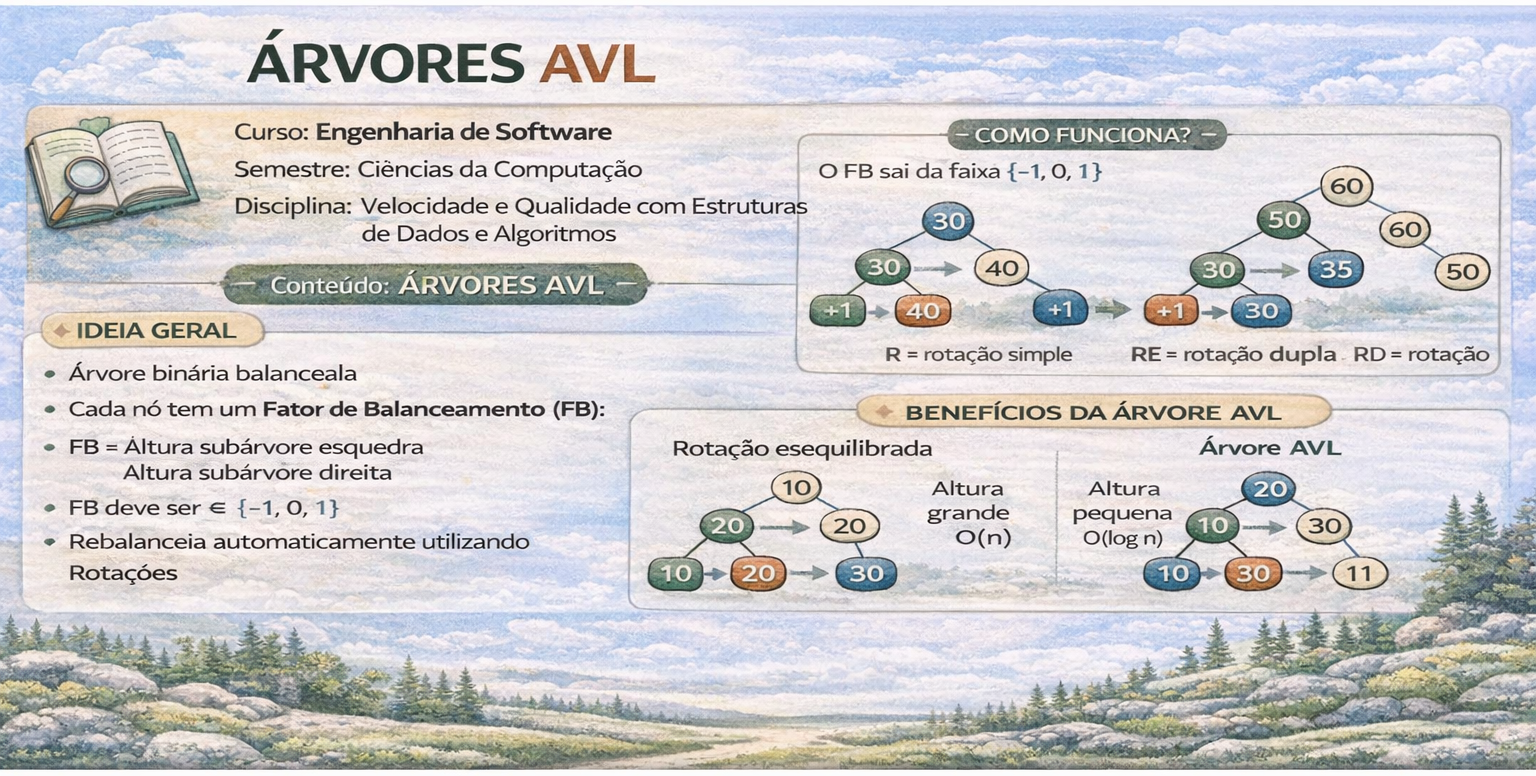